In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from astropy.io import fits
import muram as mio

In [ ]:
# This is a notebook to read the fits files that contain the level populations calculate with lightweaver code and extend them to long cubes. 
# We will perform similar extension / interpolation using MURAM cubes, for which we need a separte reading routines. 

In [2]:
# Check the spectra and level populations:
output = fits.open('/dat/milic/MURaM_SSD_che/ssd_che_full_399000_lwsynth_392.8.fits')
output.info()

Filename: /dat/milic/MURaM_SSD_che/ssd_che_full_399000_lwsynth_392.8.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   (1001, 1, 1024, 1024)   float64   
  1                1 ImageHDU         6   (1001,)   float64   
  2                1 ImageHDU         9   (401, 6, 1024, 1024)   float64   


In [3]:
pops = output[2].data
pops.shape

(1024, 1024, 6, 401)

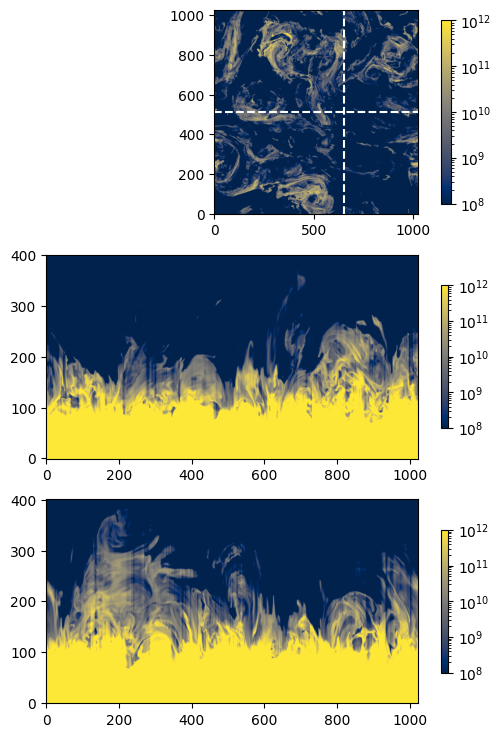

In [4]:
# A few test plots of the pops: 
i_slice = 650
j_slice = 512

plt.figure(figsize=[6,9])

plt.subplot(311)
plt.imshow(pops[:,:,0,160].T, origin="lower", cmap='cividis', norm='log', vmin=1E8, vmax=1E12)
# Add a white line where the slice is taken
plt.axvline(i_slice, color='white', linestyle='--')
plt.axhline(j_slice, color='white', linestyle='--')
plt.colorbar(shrink=0.9)

plt.subplot(312)
plt.imshow(pops[i_slice,:,0,::-1].T, origin="lower", cmap='cividis', norm='log', vmin=1E8, vmax=1E12, aspect='auto')
plt.colorbar(shrink=0.7)

plt.subplot(313)
plt.imshow(pops[:,j_slice,0,::-1].T, origin="lower", cmap='cividis', norm='log', vmin=1E8, vmax=1E12, aspect='auto')
plt.colorbar(shrink=0.7)

### Now the main part : Here we are doing extensions to long slices to be fed in the RT code:

In [5]:
# Let's cut this under a small angle and make use of the periodicity of the data to get a longer slice through the atmosphere
angle = 10  # degrees
angle_rad = np.radians(angle)

# starting point in x 
x_start = 0
y_start = 0

# these are native steps in x and y 
delta_x = 24 # in km
delta_y = 24 # in km

# We want a line that has given length, say - 10ish cubes:
line_length_km = 3E5  # in km

n_steps = int(line_length_km / delta_x)
print("number of steps is: ", n_steps)

number of steps is:  12500


In [6]:
# Get the coordinates of this steps: 
x_coords = x_start + (np.arange(n_steps) + 0.5) * delta_x * np.cos(angle_rad)
y_coords = y_start + (np.arange(n_steps) + 0.5) * delta_y * np.sin(angle_rad)

# Take the module so we know where to take the values from the original cube:
x_coords_in_box = x_coords % ((pops.shape[0]-1)*delta_x)
y_coords_in_box = y_coords % ((pops.shape[1]-1)*delta_y) 

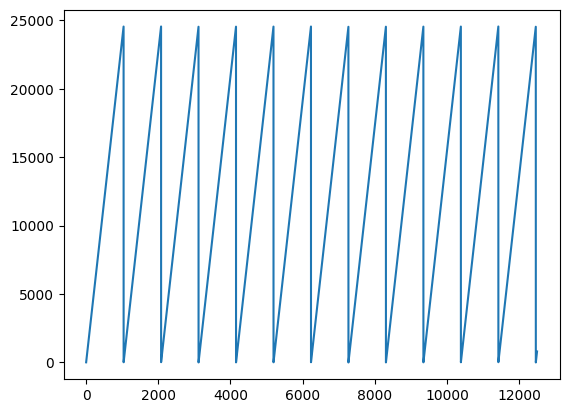

In [7]:
# Quick plot: 
plt.plot(x_coords_in_box)

In [8]:
# For a given z slice, we can now interpolate the population values along this line.
z_slice = 160  # for example, the first z slice

from scipy.interpolate import RegularGridInterpolator
# Interpolator is 2D , and it takes values from the box and then interpolates onto the "long" line, that is folded back into the box.
# Create an interpolator for the population data
interpolator = RegularGridInterpolator((np.arange(pops.shape[0])*delta_x, np.arange(pops.shape[1])*delta_y), pops[:,:,0,z_slice], bounds_error=False, fill_value=np.nan)
# Interpolate along the line
pop_along_line = interpolator(np.array([x_coords_in_box, y_coords_in_box]).T)
# check for Nans: 
if (np.sum(np.isnan(pop_along_line)) > 0):
    print("There are  NaNs in the interpolated population along the line!")
else:
    print("No NaNs in the interpolated population along the line.")


No NaNs in the interpolated population along the line.


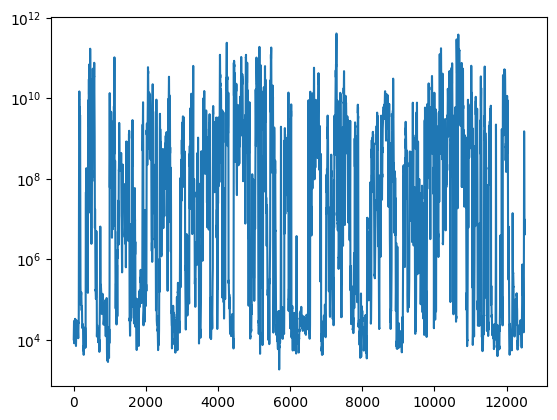

In [9]:
# Now we plot real quick with a little debug:
plt.semilogy(pop_along_line)

In [11]:
from tqdm import tqdm

In [12]:
# Now repeat this process for all z slices and create a long vertical slice:
vertical_slice = np.zeros((n_steps, pops.shape[3]))
for z in tqdm(range(pops.shape[3])):
    interpolator = RegularGridInterpolator((np.arange(pops.shape[0])*delta_x, np.arange(pops.shape[1])*delta_y), pops[:,:,0,z], bounds_error=False, fill_value=np.nan)
    vertical_slice[:,z] = interpolator(np.array([x_coords_in_box, y_coords_in_box]).T)

  0%|          | 0/401 [00:00<?, ?it/s]

100%|██████████| 401/401 [00:00<00:00, 768.37it/s]


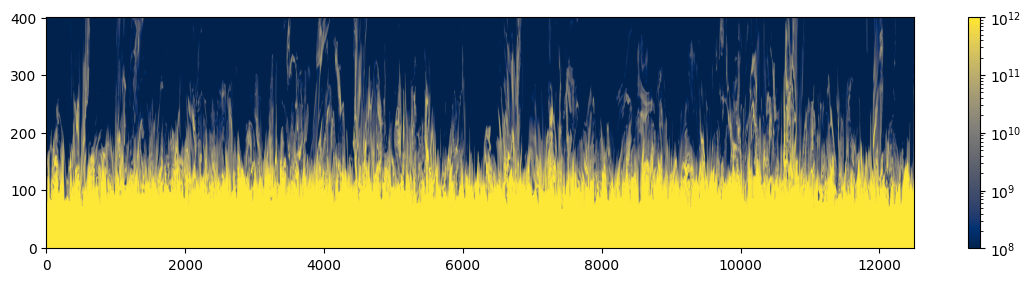

In [13]:
# Now plot this vertical slice:
plt.figure(figsize=[14,3])
plt.imshow(vertical_slice[:,::-1].T, origin="lower", cmap='cividis', norm='log', vmin=1E8, vmax=1E12, aspect='auto')
plt.colorbar()

In [14]:
# Should I pack this all for RT, together with the corresponding temperatures and velocities?
# Probably not the worst idea ever! 

path = '/dat/milic/MURaM_SSD_che/'
snapid = 399000
snap = mio.MuramSnap(path, snapid)

In [15]:
snap.available

['rho',
 'vx',
 'vy',
 'vz',
 'eint',
 'Bx',
 'By',
 'Bz',
 'sflx',
 'Temp',
 'Pres',
 'ne',
 'tau']

In [16]:
# Before everything else check where z = 0, i.e. where is tau = 1 layer
tau_mean = np.mean(snap.tau, axis=(1,2))
z_idx_ph = np.argmin(np.abs(tau_mean - 1))
print("The index of the tau=1 layer is: ", z_idx_ph, "and tau there is = ", tau_mean[z_idx_ph])

The index of the tau=1 layer is:  49 and tau there is =  1.335441


In [17]:
# Now let's make sure that the structure of this cube is the same as the structure of the intensity:
I_c = output[0].data[:,:,0,-1]

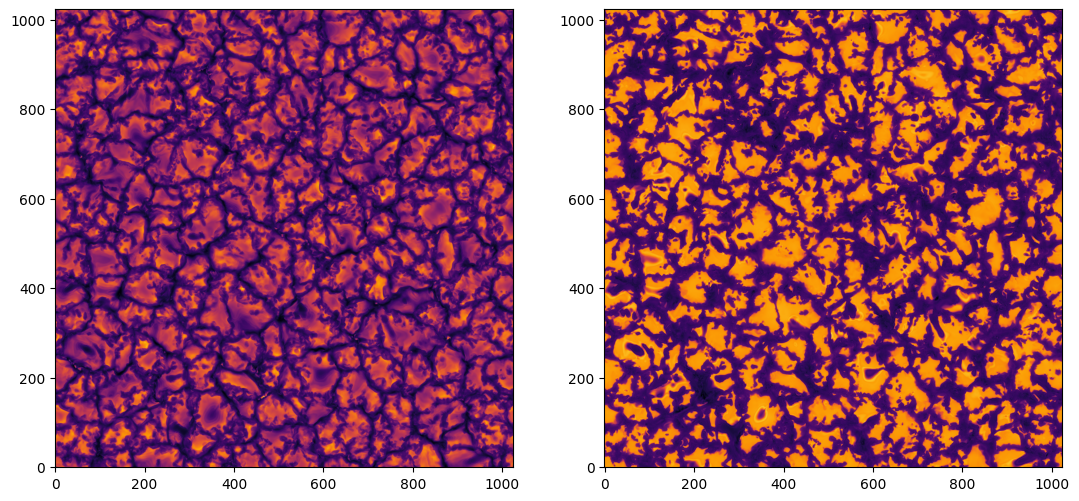

In [18]:
# Checking if it's aligned, and if transposes are needed - no
plt.figure(figsize=[13,6])
plt.subplot(121)
plt.imshow(I_c.T, origin="lower", cmap='inferno')
plt.subplot(122)
plt.imshow(snap.Temp[z_idx_ph-3,:,:].T, origin="lower", cmap='inferno')

Text(0.5, 1.0, 'log Temperature at z=2 Mm')

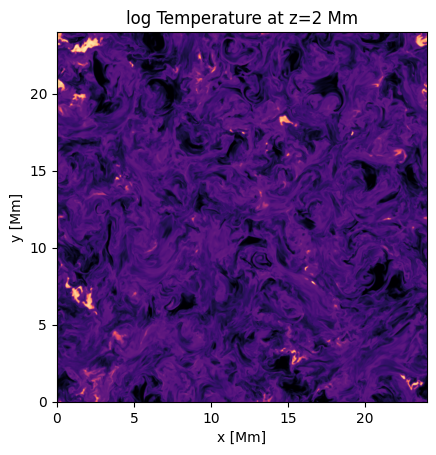

In [19]:
# Replicate the plot from the paper and do the cloning:
plt.imshow(np.log10(snap.Temp[149,:,:]), origin='lower', extent=[0, 24., 0, 24.], cmap='magma')
# Then put two dashed lines:
#plt.vlines([24/8.,24./2.], 0, 24.0, colors='white', linestyles='dashed')
# Now add some text on these white lines, rotate it by 90 degrees:
#plt.text(24/8.+0.5, 0.5, 'x=3 Mm', color='white', fontsize=14, rotation=90)
#plt.text(24/2.+0.5, 0.5, 'x=12 Mm', color='white', fontsize=14, rotation=90)  
#plt.colorbar()
plt.xlabel("x [Mm]")
plt.ylabel("y [Mm]")
plt.title("log Temperature at z=2 Mm")
#plt.text(0.02, 0.95, 'b)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

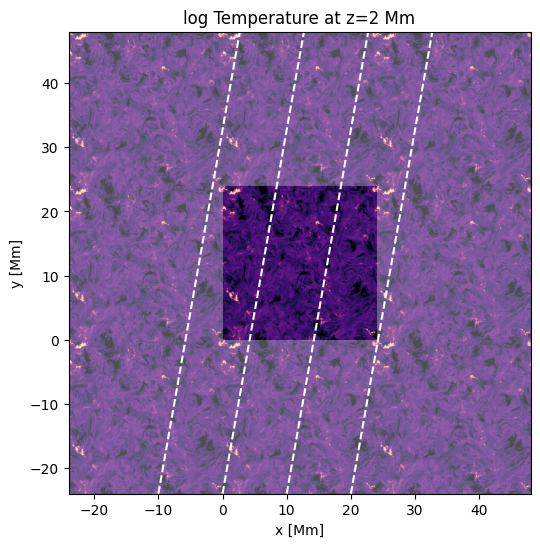

In [20]:
# Now redo the previous plot with a full 3x3 tiling: center opaque, surrounding 8 transparent.
plt.figure(figsize=[13,6])
temp_map = np.log10(snap.Temp[149,:,:])
tile_size = 24.0

for ix in [-1, 0, 1]:
    for iy in [-1, 0, 1]:
        alpha = 1.0 if (ix == 0 and iy == 0) else 0.7
        plt.imshow(
            temp_map,
            origin='lower',
            extent=[ix * tile_size, (ix + 1) * tile_size, iy * tile_size, (iy + 1) * tile_size],
            cmap='magma',
            alpha=alpha
        )

plt.xlim([-24., 48.])
plt.ylim([-24., 48.])

# Add a straight line that starts from a given x position under a given angle, and extends across the whole plot.
angle = 80  # degrees
x_start = -10
y_start = -24
x_end = 48
y_end = y_start + (x_end - x_start) * np.tan(np.radians(angle))
plt.plot([x_start, x_end], [y_start, y_end], color='white', linestyle='--')
plt.plot([x_start+10, x_end+10], [y_start, y_end], color='white', linestyle='--')
plt.plot([x_start+20, x_end+20], [y_start, y_end], color='white', linestyle='--')
plt.plot([x_start+30, x_end+30], [y_start, y_end], color='white', linestyle='--')

plt.xlabel("x [Mm]")
plt.ylabel("y [Mm]")
plt.title("log Temperature at z=2 Mm")
#plt.tight_layout()
plt.savefig("figs/temperature_tiling_ssd.png", dpi=300,bbox_inches='tight')
plt.savefig("figs/temperature_tiling_ssd.pdf", dpi=300,bbox_inches='tight')

In [ ]:
# But now we need to hardcode the limits in z that we used for the synthesis, which is a bit sad, but we can do it :-(
    
# Consulsing the synthesis code, we used z limits of 15 and 416, so we need to make sure that we take the same limits here.
z_low = 15
z_high = 416

In [ ]:
# Create a cube that contains all the needed physical quantities: 
# 0 - Temp
# 1 - Pres 
# 2 - n_e 
# 3 - V_los -> calculated by projecting
# 4 - population of the lower level
# 5 - population of the upper level

# This cube has dimensions: N_quantities, N_x, N_los_long, Nz

cube_new = np.zeros((6, pops.shape[0], n_steps, pops.shape[3])) # Carefull, this might be huge in memory!
print ("info::shape of the new cube", cube_new.shape)

In [ ]:
# Now we need to create a bigger grid which has various x-start positions, so for each start we have a list of x,y coordinates:
angle = 80  # degrees
angle_rad = np.radians(angle)
# starting point in x
x_start = 0
y_start = 0
# these are native steps in x and y
delta_x = 24 # in km
delta_y = 24 # in km
# We want a line that has given length, say - 10ish cubes:
line_length_km = 3E5  # in km
n_steps = int(line_length_km / delta_x)
print("number of steps is: ", n_steps)
# Get the coordinates of this steps:

# For each possible x_start, get the set of values:
n_los = pops.shape[0]

x_coords_grid = np.zeros((n_los, n_steps))
y_coords_grid = np.zeros((n_los, n_steps))

x_coords_grid_in_box = np.zeros((n_los, n_steps))
y_coords_grid_in_box = np.zeros((n_los, n_steps))

for i in range(n_los):
    x_start = i * delta_x
    y_start = 0
    x_coords_grid[i, :] = x_start + (np.arange(n_steps) + 0.5) * delta_x * np.cos(angle_rad)
    y_coords_grid[i, :] = y_start + (np.arange(n_steps) + 0.5) * delta_y * np.sin(angle_rad)
    
    # And then fold identically as before:
    x_coords_grid_in_box[i, :] = x_coords_grid[i, :] % ((pops.shape[0]-1)*delta_x)
    y_coords_grid_in_box[i, :] = y_coords_grid[i, :] % ((pops.shape[1]-1)*delta_y)



In [ ]:
print(y_coords_grid_in_box[0])

In [ ]:
# Loop in z:
# What would be the easiest way to parallelize this? 

from tqdm import tqdm


for k in tqdm(range(pops.shape[3])):
    
    interpolator_temp = RegularGridInterpolator((np.arange(pops.shape[0])*delta_x, np.arange(pops.shape[1])*delta_y), snap.Temp[k,:,:], bounds_error=False, fill_value=np.nan)
    
    # For each los interpolate:
    for i in range(0,n_los,1):
    
        cube_new[0,i, :, k] = interpolator_temp(np.array([x_coords_grid_in_box[i, :], y_coords_grid_in_box[i, :]]).T).reshape((n_steps,))
    
    interpolator_pres = RegularGridInterpolator((np.arange(pops.shape[0])*delta_x, np.arange(pops.shape[1])*delta_y), snap.Pres[k,:,:], bounds_error=False, fill_value=np.nan)
    
    for i in range(n_los):
        cube_new[1,i, :, k] = interpolator_pres(np.array([x_coords_grid_in_box[i, :], y_coords_grid_in_box[i, :]]).T).reshape((n_steps,))
    
    interpolator_ne = RegularGridInterpolator((np.arange(pops.shape[0])*delta_x, np.arange(pops.shape[1])*delta_y), snap.ne[k,:,:], bounds_error=False, fill_value=np.nan)
    
    for i in range(n_los):
        cube_new[2,i, :, k] = interpolator_ne(np.array([x_coords_grid_in_box[i, :], y_coords_grid_in_box[i, :]]).T).reshape((n_steps,))
    
    # For V_los we need to calculate it by projecting the velocity vector onto the line of sight. 
    # This is a bit more complicated, but we can do it by first calculating the velocity vector and then projecting it onto the line of sight.
    
    v_los = snap.vy[k,:,:] * np.cos(angle_rad) + snap.vz[k,:,:] * np.sin(angle_rad)
    
    interpolator_v_los = RegularGridInterpolator((np.arange(pops.shape[0])*delta_x, np.arange(pops.shape[1])*delta_y), v_los, bounds_error=False, fill_value=np.nan)
    for i in range(n_los):
        cube_new[3,i, :, k] = interpolator_v_los(np.array([x_coords_grid_in_box[i, :], y_coords_grid_in_box[i, :]]).T).reshape((n_steps,))    
        
    # Then come the level populations that are also interpolated but from a different array:
    interpolator_pop_lower = RegularGridInterpolator((np.arange(pops.shape[0])*delta_x, np.arange(pops.shape[1])*delta_y), pops[:,:,0,k], bounds_error=False, fill_value=np.nan)
    for i in range(n_los):
        cube_new[4,i, :, k] = interpolator_pop_lower(np.array([x_coords_grid_in_box[i, :], y_coords_grid_in_box[i, :]]).T).reshape((n_steps,))
    
    interpolator_pop_upper = RegularGridInterpolator((np.arange(pops.shape[0])*delta_x, np.arange(pops.shape[1])*delta_y), pops[:,:,1,k], bounds_error=False, fill_value=np.nan)
    for i in range(n_los):
        cube_new[5,i, :, k] = interpolator_pop_upper(np.array([x_coords_grid_in_box[i, :], y_coords_grid_in_box[i, :]]).T).reshape((n_steps,))

In [ ]:
plt.figure(figsize=[14,6])
plt.imshow(cube_new[0,:,:,55], origin="lower", cmap='inferno', aspect='equal')
plt.colorbar()

In [ ]:
# Flip the last two entries because of how optical depth works: 
cube_new[4,:, :, :] = cube_new[4,:, :, ::-1]
cube_new[5,:, :, :] = cube_new[5,:, :, ::-1]


In [ ]:
plt.figure(figsize=[14,6])
for i in range(4):
    plt.subplot(4,1,i+1)
    plt.imshow(cube_new[0,i*211,:,:].T, origin="lower", cmap='inferno', aspect='equal', norm='log',vmin=3E3, vmax=1E6)
    plt.colorbar()

In [ ]:
# Now in a different plot we plot, for one slice, all the physical parameters: 
# But due to the different dynamic ranges we need to plot them separately, and also we need to use a log scale for some of them.
plt.figure(figsize=[16,5])

plt.subplot(5,1,1)
plt.imshow(cube_new[0,0,:,:].T, origin="lower", cmap='inferno', aspect='equal', norm='log', vmin=3E3, vmax=1E6)
plt.title("Temperature")
plt.colorbar()

plt.subplot(5,1,2)
plt.imshow(cube_new[1,0,:,:].T, origin="lower", cmap='cividis', aspect='equal', norm='log', vmin=1E-2, vmax=1E2)
plt.title("Gas pressure")
plt.colorbar()

plt.subplot(5,1,3)
plt.imshow(cube_new[2,0,:,:].T, origin="lower", cmap='cividis', aspect='equal', norm='log', vmin=1E7, vmax=1E14)
plt.title("Electron density")
plt.colorbar()

plt.subplot(5,1,4)
plt.imshow(cube_new[3,0,:,:].T/1E5, origin="lower", cmap='bwr', aspect='equal', vmin=-10, vmax=10)
plt.title("LOS velocity")
plt.colorbar()

plt.subplot(5,1,5)
plt.imshow(cube_new[4,0,:,:].T, origin="lower", cmap='cividis', aspect='equal', norm='log')
plt.title("Population of the lower level")    
plt.colorbar()
plt.tight_layout()
plt.savefig("physical_parameters_along_los.png", dpi=300, bbox_inches='tight')

In [ ]:
# Cube looks different for different los, which is good. So let's save this in a cube and then write a simple RT solver!
# Do I know better than fits? Probably not. But it will be huge file :(

# Vigeesh says to do hdf5, so let's do it!
import h5py

# Create some sort of dictionary to save the cube and the corresponding coordinates:
data_to_save = {
    "Temperature": cube_new[0],
    "Pressure": cube_new[1],
    "Electron_density": cube_new[2],
    "LOS_velocity": cube_new[3],
    "Population_lower_level": cube_new[4],
    "Population_upper_level": cube_new[5],
    "x_coords_grid_in_box": x_coords_grid_in_box,
    "y_coords_grid_in_box": y_coords_grid_in_box,
    "x_coords_grid": x_coords_grid,
    "y_coords_grid": y_coords_grid
}


In [ ]:
# And then save to the file:
with h5py.File('/dat/milic/SUSI_modeling/extended_off_limb_ssd_cube_paper_angle_80.h5', 'w') as f:
    for key, value in data_to_save.items():
        f.create_dataset(key, data=value)
        

In [ ]:
# Now readout the cube and plot the same thing as before, to make sure that we saved it correctly:
import h5py
cube = h5py.File('/dat/milic/SUSI_modeling/extended_off_limb_cube_paper_angle_80.h5', 'r')
temp_cube = cube["Temperature"][:]


In [ ]:
temp_cube.shape

In [ ]:
cube.keys()

In [ ]:
vlos_cube = cube["LOS_velocity"][:]

In [ ]:
plt.figure(figsize=[17,3])
plt.imshow(temp_cube[0, :1024, :].T, cmap='inferno', origin='lower', norm='log')
plt.colorbar()

In [ ]:
plt.figure(figsize=[17,3])
plt.imshow(vlos_cube[0, :1024, :].T/1E5, cmap='bwr', origin='lower', norm='linear',vmin=-20, vmax=20)
plt.colorbar()

In [ ]:
# Do the calculation of the curves:
def create_curved_grid(z_index):
    
    # Meant for testing, but we can also just call it from create ray and then interpolate the slice to get the parameters at each point.
    N_steps = 10001
    
    delta_los = 24.0
    delta_z = 20.0  
    
    s = (np.arange(N_steps) - N_steps // 2) * delta_los # km    
    R_at_the_tangent = 696.0E3 + z_index * delta_z # km
    
    angle = np.arctan(s / R_at_the_tangent)
    y = R_at_the_tangent * angle
    z = z_index * delta_z + np.sqrt(s**2 + R_at_the_tangent**2) - R_at_the_tangent
    
    return s, y, z

In [ ]:
s,y,z = create_curved_grid(50)

In [ ]:
NY = temp_cube.shape[1]
NZ = temp_cube.shape[2]

In [ ]:
# Plot vertical slice of the temperature and overplot the curve:
plt.figure(figsize=[8,2])
plt.imshow(temp_cube[0,:,:].T, origin="lower", cmap='inferno', aspect='auto', norm='log', vmin=3E3, vmax=1E6, extent=[-NY//2*0.024, NY//2*0.024, 0, NZ*0.02])
plt.plot(s/1E3, z/1E3, color='red', linestyle='--', linewidth=4)
plt.ylim([0,8])
#plt.colorbar()
plt.title("Vertical slice of the Temperature")
plt.xlabel("Path along the solar surface [Mm]")
plt.ylabel("Height [Mm]")
plt.savefig("figs/vertical_slice_with_curve.png", dpi=300, bbox_inches='tight')
plt.savefig("figs/vertical_slice_with_curve.pdf", dpi=300, bbox_inches='tight')